# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 26: STRUCTURED MULTI-LABEL BASELINE ON CANDIDATE 150 LABELS
# ============================================================
# Purpose:
# This notebook trains the first structured multi-label genre
# prediction baseline using the 150 candidate metadata genres.
#
# The goal is to:
# 1. Load the candidate multi-label master table
# 2. Align engineered audio features to the same tracks
# 3. Remove rows with no candidate labels
# 4. Train structured multi-label baseline models
# 5. Evaluate using proper multi-label metrics
# 6. Save outputs for the next modelling phase
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    f1_score,
    hamming_loss,
    accuracy_score,
    precision_score,
    recall_score
)

In [2]:
# ============================================================
# 2. LOAD MULTI-LABEL MASTER TABLE AND FEATURES
# ============================================================

master_df = pd.read_csv("../data/processed/multilabel_candidate_master_table.csv")

features = pd.read_csv(
    "../data/raw/metadata/features.csv",
    header=[0, 1, 2],
    index_col=0
)

features.index = features.index.astype(int)

print("Candidate multi-label master shape:", master_df.shape)
print("Features shape:", features.shape)

display(master_df.head())

Candidate multi-label master shape: (81574, 157)
Features shape: (106574, 518)


,track_id,split,subset,genre_top,title,audio_path,audio_exists,genre_1,genre_2,genre_3,...,genre_693,genre_695,genre_741,genre_763,genre_810,genre_811,genre_906,genre_1156,genre_1193,genre_1235
0,20,training,large,NaN,Spiritual Level,../data/raw/audio/fma_large\000\000020.mp3,True,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,26,training,large,NaN,Where is your Love?,../data/raw/audio/fma_large\000\000026.mp3,True,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,30,training,large,NaN,Too Happy,../data/raw/audio/fma_large\000\000030.mp3,True,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,46,training,large,NaN,Yosemite,../data/raw/audio/fma_large\000\000046.mp3,True,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,48,training,large,NaN,Light of Light,../data/raw/audio/fma_large\000\000048.mp3,True,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# ============================================================
# 3. IDENTIFY LABEL COLUMNS
# ============================================================

label_cols = [
    col for col in master_df.columns
    if col.startswith("genre_") and col.replace("genre_", "").isdigit()
]

print("Number of candidate label columns:", len(label_cols))
print("First 10 label columns:", label_cols[:10])
print("\nNon-label genre-like columns:")
print([col for col in master_df.columns if col.startswith("genre_") and col not in label_cols])

Number of candidate label columns: 150
First 10 label columns: ['genre_1', 'genre_2', 'genre_3', 'genre_4', 'genre_5', 'genre_6', 'genre_7', 'genre_8', 'genre_9', 'genre_10']

Non-label genre-like columns:
['genre_top']


In [4]:
# ============================================================
# 4. REMOVE TRACKS WITH NO CANDIDATE LABELS
# ============================================================

master_df["candidate_label_count"] = master_df[label_cols].sum(axis=1)

usable_df = master_df[master_df["candidate_label_count"] > 0].copy().reset_index(drop=True)

print("Original candidate master shape:", master_df.shape)
print("Usable candidate multi-label shape:", usable_df.shape)

print("\nSplit distribution after filtering:")
print(usable_df["split"].value_counts())

print("\nCandidate label count summary:")
print(usable_df["candidate_label_count"].describe())

Original candidate master shape: (81574, 158)
Usable candidate multi-label shape: (79343, 158)

Split distribution after filtering:
split
training      62452
test           8548
validation     8343
Name: count, dtype: int64

Candidate label count summary:
count    79343.000000
mean         3.679329
std          1.735141
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         31.000000
Name: candidate_label_count, dtype: float64


In [5]:
# ============================================================
# 5. ALIGN FEATURES TO USABLE TRACKS
# ============================================================

usable_df["track_id"] = usable_df["track_id"].astype(int)

track_ids = usable_df["track_id"].tolist()
features_aligned = features.loc[track_ids].copy()

features_aligned = features_aligned.reset_index(drop=True)
usable_df = usable_df.reset_index(drop=True)

print("Aligned features shape:", features_aligned.shape)
print("Usable dataframe shape:", usable_df.shape)

Aligned features shape: (79343, 518)
Usable dataframe shape: (79343, 158)


In [6]:
# ============================================================
# 6. FLATTEN FEATURE COLUMNS
# ============================================================

features_aligned.columns = [
    "_".join([str(level) for level in col]).strip()
    for col in features_aligned.columns.to_flat_index()
]

print("Flattened features shape:", features_aligned.shape)
display(features_aligned.head())

Flattened features shape: (79343, 518)


,chroma_cens_kurtosis_01,chroma_cens_kurtosis_02,chroma_cens_kurtosis_03,chroma_cens_kurtosis_04,chroma_cens_kurtosis_05,chroma_cens_kurtosis_06,chroma_cens_kurtosis_07,chroma_cens_kurtosis_08,chroma_cens_kurtosis_09,chroma_cens_kurtosis_10,...,tonnetz_std_04,tonnetz_std_05,tonnetz_std_06,zcr_kurtosis_01,zcr_max_01,zcr_mean_01,zcr_median_01,zcr_min_01,zcr_skew_01,zcr_std_01
0,-0.193837,-0.198527,0.201546,0.258556,0.775204,0.084794,-0.289294,-0.816410,0.043851,-0.804761,...,0.095003,0.022492,0.021355,16.669037,0.469727,0.047225,0.040039,0.000977,3.189831,0.030993
1,-0.699535,-0.684158,0.048825,0.042659,-0.818967,-0.917123,-0.901834,-0.066845,-0.291037,-0.861782,...,0.103717,0.025541,0.023846,41.645809,0.250488,0.018388,0.015625,0.000000,4.690596,0.014598
2,-0.721487,-0.848560,0.890904,0.088620,-0.445513,-1.271170,-1.240190,-1.343765,-0.905600,2.671522,...,0.141693,0.020426,0.025418,8.166595,0.546875,0.054417,0.036133,0.002441,2.244708,0.052674
3,-0.119708,-0.858814,2.362546,0.106584,-1.315912,-1.220354,-1.668162,-0.516033,-0.536395,11.025053,...,0.132632,0.033212,0.021310,14.731083,0.223633,0.036601,0.032227,0.000000,2.848736,0.020713
4,-1.054053,0.932339,0.528064,-1.035338,-1.000682,-1.119304,1.166990,-1.002603,-1.094999,-0.725826,...,0.141955,0.024654,0.025203,24.550789,0.371582,0.033015,0.022461,0.000000,4.406733,0.039016


In [7]:
# ============================================================
# 7. PREPARE X AND Y
# ============================================================

X = features_aligned.copy()
X = X.select_dtypes(include=["number"])
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())
X = X.astype(np.float32)

Y = usable_df[label_cols].copy().astype(np.uint8)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("\nAverage labels per track:", Y.sum(axis=1).mean())
print("Max labels on a track:", Y.sum(axis=1).max())

X shape: (79343, 518)
Y shape: (79343, 150)

Average labels per track: 3.67932898932483
Max labels on a track: 31


In [8]:
# ============================================================
# 8A. CREATE TRAIN / VALIDATION / TEST SPLITS
# ============================================================

split = usable_df["split"].astype(str)

train_mask = (split == "training").values
val_mask = (split == "validation").values
test_mask = (split == "test").values

X_train = X.loc[train_mask].copy()
Y_train = Y.loc[train_mask].copy()

X_val = X.loc[val_mask].copy()
Y_val = Y.loc[val_mask].copy()

X_test = X.loc[test_mask].copy()
Y_test = Y.loc[test_mask].copy()

print("Train:", X_train.shape, Y_train.shape)
print("Validation:", X_val.shape, Y_val.shape)
print("Test:", X_test.shape, Y_test.shape)

Train: (62452, 518) (62452, 150)
Validation: (8343, 518) (8343, 150)
Test: (8548, 518) (8548, 150)


In [9]:
# ============================================================
# 8B. SAMPLE THE SPLITS FOR A SAFE BASELINE
# ============================================================

SEED = 42

MAX_TRAIN_ROWS = 20000
MAX_VAL_ROWS = 5000
MAX_TEST_ROWS = 5000

if len(X_train) > MAX_TRAIN_ROWS:
    train_idx = X_train.sample(n=MAX_TRAIN_ROWS, random_state=SEED).index
    X_train = X_train.loc[train_idx].copy()
    Y_train = Y_train.loc[train_idx].copy()

if len(X_val) > MAX_VAL_ROWS:
    val_idx = X_val.sample(n=MAX_VAL_ROWS, random_state=SEED).index
    X_val = X_val.loc[val_idx].copy()
    Y_val = Y_val.loc[val_idx].copy()

if len(X_test) > MAX_TEST_ROWS:
    test_idx = X_test.sample(n=MAX_TEST_ROWS, random_state=SEED).index
    X_test = X_test.loc[test_idx].copy()
    Y_test = Y_test.loc[test_idx].copy()

print("Sampled safe baseline sizes:")
print("Train:", X_train.shape, Y_train.shape)
print("Validation:", X_val.shape, Y_val.shape)
print("Test:", X_test.shape, Y_test.shape)

Sampled safe baseline sizes:
Train: (20000, 518) (20000, 150)
Validation: (5000, 518) (5000, 150)
Test: (5000, 518) (5000, 150)


In [10]:
# ============================================================
# 9. SCALE FEATURES
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print("Scaling complete.")

Scaling complete.


In [11]:
# ============================================================
# 10. DEFINE EVALUATION HELPERS
# ============================================================

def evaluate_multilabel(y_true, y_pred, name="Model"):
    results = {
        "Model": name,
        "Micro F1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Samples F1": f1_score(y_true, y_pred, average="samples", zero_division=0),
        "Micro Precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "Micro Recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "Hamming Loss": hamming_loss(y_true, y_pred),
        "Subset Accuracy": accuracy_score(y_true, y_pred)
    }
    return results

def get_score_matrix(model, X_input):
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_input)
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_input)
    else:
        raise ValueError("Model does not support predict_proba or decision_function.")
    return np.asarray(scores)

def precision_recall_at_k(y_true, score_matrix, k=3):
    y_true = np.asarray(y_true)
    topk_idx = np.argsort(-score_matrix, axis=1)[:, :k]

    precision_vals = []
    recall_vals = []

    for i in range(y_true.shape[0]):
        true_idx = np.where(y_true[i] == 1)[0]
        if len(true_idx) == 0:
            continue

        pred_idx = topk_idx[i]
        hits = len(set(pred_idx).intersection(set(true_idx)))

        precision_vals.append(hits / k)
        recall_vals.append(hits / len(true_idx))

    return float(np.mean(precision_vals)), float(np.mean(recall_vals))

In [12]:
# ============================================================
# 11. TRAIN ONE-VS-REST SGD LOGISTIC
# ============================================================

ovr_sgd_log = OneVsRestClassifier(
    SGDClassifier(
        loss="log_loss",
        alpha=1e-4,
        max_iter=20,
        tol=1e-3,
        class_weight="balanced",
        random_state=42
    ),
    n_jobs=1
)

ovr_sgd_log.fit(X_train_scaled, Y_train)

Y_val_pred_log = ovr_sgd_log.predict(X_val_scaled)
val_scores_log = get_score_matrix(ovr_sgd_log, X_val_scaled)

log_results = evaluate_multilabel(Y_val, Y_val_pred_log, name="OVR SGD Logistic")

p_at_3_log, r_at_3_log = precision_recall_at_k(Y_val.values, val_scores_log, k=3)
p_at_5_log, r_at_5_log = precision_recall_at_k(Y_val.values, val_scores_log, k=5)

log_results["Precision@3"] = p_at_3_log
log_results["Recall@3"] = r_at_3_log
log_results["Precision@5"] = p_at_5_log
log_results["Recall@5"] = r_at_5_log

print("Finished OVR SGD Logistic.")
print(log_results)

c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider i

Finished OVR SGD Logistic.
{'Model': 'OVR SGD Logistic', 'Micro F1': 0.15931854766589162, 'Macro F1': 0.08013485821520762, 'Samples F1': 0.15868185647935196, 'Micro Precision': 0.09322263018811976, 'Micro Recall': 0.547508067407673, 'Hamming Loss': 0.150408, 'Subset Accuracy': 0.0, 'Precision@3': 0.05793333333333332, 'Recall@3': 0.045224435786435785, 'Precision@5': 0.05536, 'Recall@5': 0.0719961818181818}


In [13]:
# ============================================================
# 12. TRAIN ONE-VS-REST SGD HINGE
# ============================================================

ovr_sgd_hinge = OneVsRestClassifier(
    SGDClassifier(
        loss="hinge",
        alpha=1e-4,
        max_iter=20,
        tol=1e-3,
        class_weight="balanced",
        random_state=42
    ),
    n_jobs=1
)

ovr_sgd_hinge.fit(X_train_scaled, Y_train)

Y_val_pred_hinge = ovr_sgd_hinge.predict(X_val_scaled)
val_scores_hinge = get_score_matrix(ovr_sgd_hinge, X_val_scaled)

hinge_results = evaluate_multilabel(Y_val, Y_val_pred_hinge, name="OVR SGD Hinge")

p_at_3_hinge, r_at_3_hinge = precision_recall_at_k(Y_val.values, val_scores_hinge, k=3)
p_at_5_hinge, r_at_5_hinge = precision_recall_at_k(Y_val.values, val_scores_hinge, k=5)

hinge_results["Precision@3"] = p_at_3_hinge
hinge_results["Recall@3"] = r_at_3_hinge
hinge_results["Precision@5"] = p_at_5_hinge
hinge_results["Recall@5"] = r_at_5_hinge

print("Finished OVR SGD Hinge.")
print(hinge_results)

c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider i

Finished OVR SGD Hinge.
{'Model': 'OVR SGD Hinge', 'Micro F1': 0.16272981674841272, 'Macro F1': 0.07915137082646072, 'Samples F1': 0.1630859834765631, 'Micro Precision': 0.09537161953636837, 'Micro Recall': 0.5540132151820929, 'Hamming Loss': 0.1484, 'Subset Accuracy': 0.0, 'Precision@3': 0.02493333333333333, 'Recall@3': 0.01941611111111111, 'Precision@5': 0.03, 'Recall@5': 0.03788651515151515}


In [14]:
# ============================================================
# 13. VALIDATION COMPARISON SUMMARY
# ============================================================

validation_results_df = pd.DataFrame([log_results, hinge_results])

print("Validation comparison summary:")
display(validation_results_df)

Validation comparison summary:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Precision@3,Recall@3,Precision@5,Recall@5
0,OVR SGD Logistic,0.159319,0.080135,0.158682,0.093223,0.547508,0.150408,0.0,0.057933,0.045224,0.05536,0.071996
1,OVR SGD Hinge,0.162730,0.079151,0.163086,0.095372,0.554013,0.148400,0.0,0.024933,0.019416,0.03000,0.037887


In [15]:
# ============================================================
# 14. SELECT BEST MODEL BASED ON MICRO F1
# ============================================================

best_model_name = validation_results_df.sort_values("Micro F1", ascending=False).iloc[0]["Model"]

print("Best multi-label structured model:", best_model_name)

if best_model_name == "OVR SGD Logistic":
    best_model = ovr_sgd_log
else:
    best_model = ovr_sgd_hinge

Best multi-label structured model: OVR SGD Hinge


In [16]:
# ============================================================
# 15. FINAL TEST EVALUATION
# ============================================================

Y_test_pred = best_model.predict(X_test_scaled)
test_scores = get_score_matrix(best_model, X_test_scaled)

test_results = evaluate_multilabel(Y_test, Y_test_pred, name=best_model_name)

p_at_3_test, r_at_3_test = precision_recall_at_k(Y_test.values, test_scores, k=3)
p_at_5_test, r_at_5_test = precision_recall_at_k(Y_test.values, test_scores, k=5)

test_results["Precision@3"] = p_at_3_test
test_results["Recall@3"] = r_at_3_test
test_results["Precision@5"] = p_at_5_test
test_results["Recall@5"] = r_at_5_test

print("Final test results:")
print(test_results)

Final test results:
{'Model': 'OVR SGD Hinge', 'Micro F1': 0.1611562096957742, 'Macro F1': 0.0836051945282357, 'Samples F1': 0.161468435208297, 'Micro Precision': 0.0937009263343626, 'Micro Recall': 0.5753521126760563, 'Hamming Loss': 0.147424, 'Subset Accuracy': 0.0, 'Precision@3': 0.024866666666666665, 'Recall@3': 0.019935714285714282, 'Precision@5': 0.03196, 'Recall@5': 0.042197460317460314}


In [17]:
# ============================================================
# 16. SAVE MODELS AND OUTPUTS
# ============================================================

os.makedirs("../models", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

joblib.dump(best_model, "../models/best_structured_multilabel_candidate150.joblib")
joblib.dump(scaler, "../models/structured_multilabel_candidate150_scaler.joblib")

validation_results_df.to_csv(
    "../data/processed/structured_multilabel_candidate150_validation_results.csv",
    index=False
)

pd.DataFrame([test_results]).to_csv(
    "../data/processed/structured_multilabel_candidate150_test_results.csv",
    index=False
)

# Save the correct validation score matrix based on the selected best model
if best_model_name == "OVR SGD Logistic":
    best_val_scores = val_scores_log
else:
    best_val_scores = val_scores_hinge

np.save("../data/processed/structured_multilabel_candidate150_val_scores.npy", best_val_scores)
np.save("../data/processed/structured_multilabel_candidate150_test_scores.npy", test_scores)

np.save("../data/processed/structured_multilabel_candidate150_y_val.npy", Y_val.values)
np.save("../data/processed/structured_multilabel_candidate150_y_test.npy", Y_test.values)
np.save("../data/processed/structured_multilabel_candidate150_label_columns.npy", np.array(label_cols))

with open("../data/processed/best_structured_multilabel_candidate150_name.txt", "w") as f:
    f.write(best_model_name)

print("Saved multi-label structured baseline outputs.")

Saved multi-label structured baseline outputs.


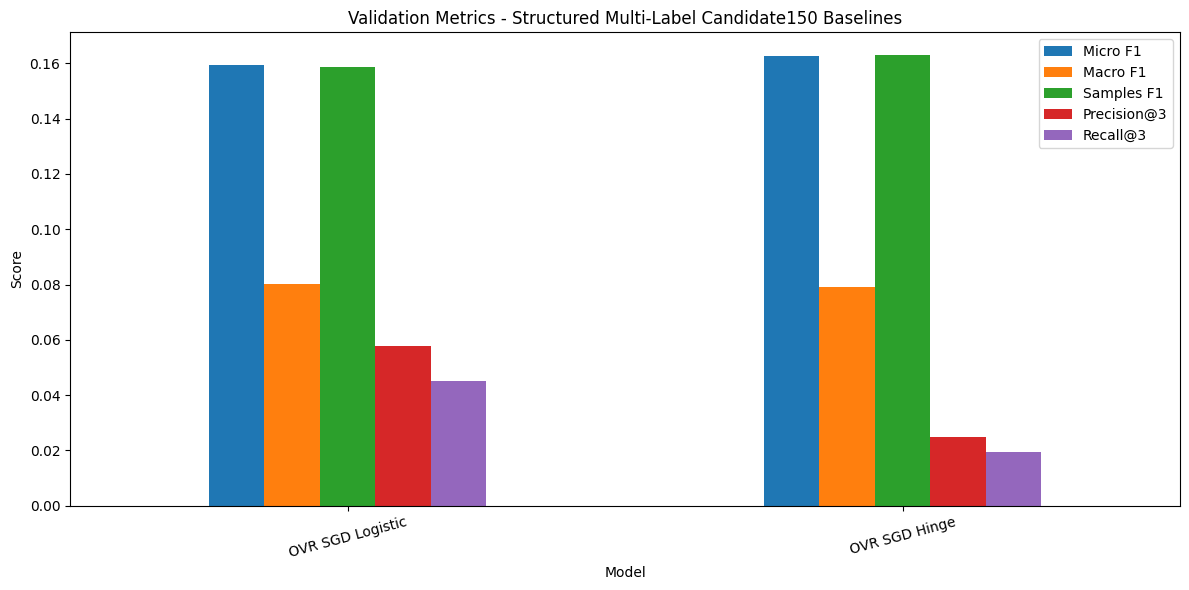

In [18]:
# ============================================================
# 17. PLOT MAIN VALIDATION METRICS
# ============================================================

plot_cols = ["Micro F1", "Macro F1", "Samples F1", "Precision@3", "Recall@3"]

plot_df = validation_results_df.set_index("Model")[plot_cols]

ax = plot_df.plot(kind="bar", figsize=(12, 6))
ax.set_title("Validation Metrics - Structured Multi-Label Candidate150 Baselines")
ax.set_ylabel("Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# 18. INTERPRETATION NOTES
# ============================================================

print("1. This notebook establishes the first structured multi-label baseline on the 150 candidate labels.")
print("2. Rows with no candidate labels were removed so the model is trained only on usable candidate-label examples.")
print("3. Multi-label evaluation uses F1, Hamming loss, subset accuracy, and top-k retrieval-style metrics.")
print("4. The saved outputs can support future comparison with audio multi-label and hybrid multi-label models.")
print("5. The next logical step is an audio multi-label baseline or a MongoDB-driven prediction/retrieval workflow.")

1. This notebook establishes the first structured multi-label baseline on the 150 candidate labels.
2. Rows with no candidate labels were removed so the model is trained only on usable candidate-label examples.
3. Multi-label evaluation uses F1, Hamming loss, subset accuracy, and top-k retrieval-style metrics.
4. The saved outputs can support future comparison with audio multi-label and hybrid multi-label models.
5. The next logical step is an audio multi-label baseline or a MongoDB-driven prediction/retrieval workflow.
